# TIỀN XỬ LÝ DỮ LIỆU

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from PIL import Image
from sklearn.model_selection import train_test_split

In [16]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [18]:
# 1. LOAD DỮ LIỆU
print("Đang đọc dữ liệu CSV...")
INPUT_DIR = "/kaggle/input/data"
CSV_PATH = os.path.join(INPUT_DIR, "Data_Entry_2017.csv")
df = pd.read_csv(CSV_PATH)

print(f"Tổng số dòng dữ liệu ban đầu: {len(df)}")
display(df.head())

Đang đọc dữ liệu CSV...
Tổng số dòng dữ liệu ban đầu: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [32]:
# 2. KIỂM TRA
print("\n--- PHÂN TÍCH CỘT TUỔI (PATIENT AGE) ---")
print(df['Patient Age'].describe())

# Kiểm tra xem có bao nhiêu người tuổi > 100 (Dữ liệu nhiễu)
outliers = df[df['Patient Age'] > 100]
print(f"\nPhát hiện {len(outliers)} trường hợp tuổi > 100:")
print(outliers[['Image Index', 'Patient Age']])


--- PHÂN TÍCH CỘT TUỔI (PATIENT AGE) ---
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64

Phát hiện 16 trường hợp tuổi > 100:
             Image Index  Patient Age
20852   00005567_000.png          412
46965   00011973_002.png          414
48284   00012238_010.png          148
55742   00013950_000.png          148
58650   00014520_026.png          150
62929   00015558_000.png          149
74884   00018366_044.png          152
78795   00019346_000.png          151
84810   00020900_002.png          411
85404   00021047_002.png          412
86264   00021275_003.png          413
91369   00022811_000.png          412
95794   00025206_000.png          153
98495   00026028_001.png          154
101194  00026871_000.png          155
104590  00027989_000.png          155


Text(0.5, 1.0, 'Biểu đồ Hộp (Boxplot) - Tuổi của bệnh nhân')

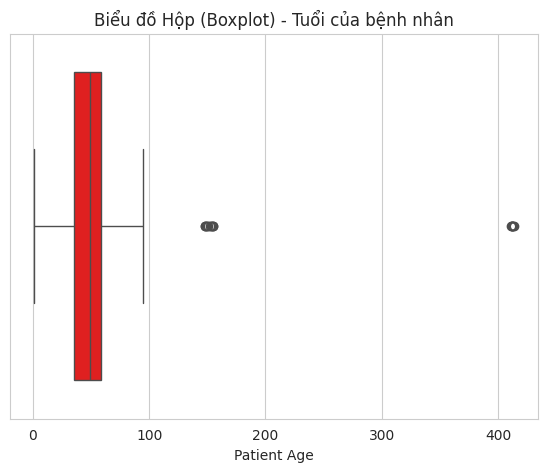

In [20]:
# VẼ BIỂU ĐỒ HỘP
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Patient Age'], color='red')
plt.title("Biểu đồ Hộp (Boxplot) - Tuổi của bệnh nhân")

In [33]:
# 3. KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES)
print("\n--- KIỂM TRA MISSING VALUES ---")
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print(missing_data[missing_data > 0])
else:
    print("Không có giá trị bị thiếu (Missing Values).")


--- KIỂM TRA MISSING VALUES ---
Unnamed: 11    112120
dtype: int64


In [34]:
# 4. LÀM SẠCH (CLEANING)
# Loại bỏ tuổi > 100
df_clean = df[(df['Patient Age'] > 0) & (df['Patient Age'] < 100)].copy()
print(f"-> Đã loại bỏ {len(df) - len(df_clean)} dòng dữ liệu lỗi.")
print(f"-> Dữ liệu sạch còn lại: {len(df_clean)} dòng.")

-> Đã loại bỏ 16 dòng dữ liệu lỗi.
-> Dữ liệu sạch còn lại: 112104 dòng.


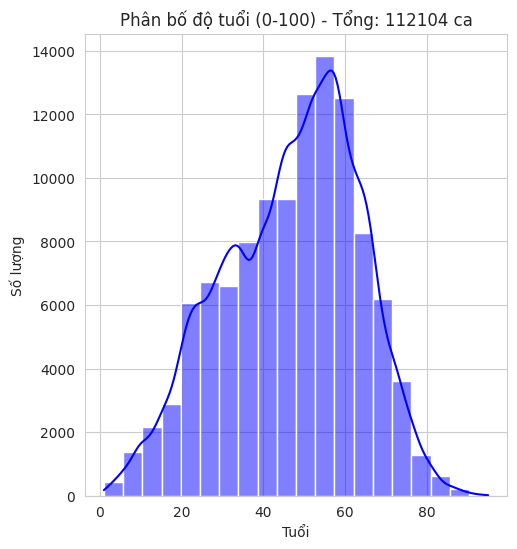

In [35]:
# VẼ BIỂU ĐỒ phân bố
plt.subplot(1, 2, 2)
sns.histplot(df_clean['Patient Age'], bins=20, kde=True, color='blue')
plt.title(f"Phân bố độ tuổi (0-100) - Tổng: {len(df_clean)} ca")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")
plt.show()


--- PHÂN TÍCH GIỚI TÍNH ---


/tmp/ipykernel_55/181480979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Patient Gender', palette='pastel')


Text(0.5, 1.0, 'Số lượng bệnh nhân theo Giới tính')

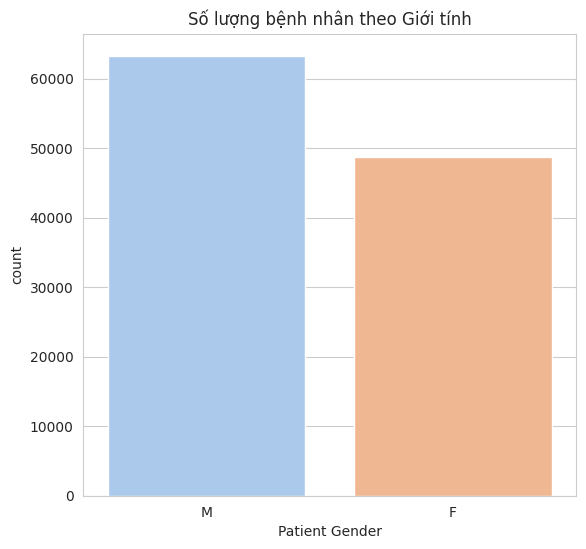

In [36]:
# 3. PHÂN TÍCH THEO GIỚI TÍNH
print("\n--- PHÂN TÍCH GIỚI TÍNH ---")
plt.figure(figsize=(14, 6))

# Biểu đồ đếm số lượng Nam/Nữ
plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='Patient Gender', palette='pastel')
plt.title("Số lượng bệnh nhân theo Giới tính")

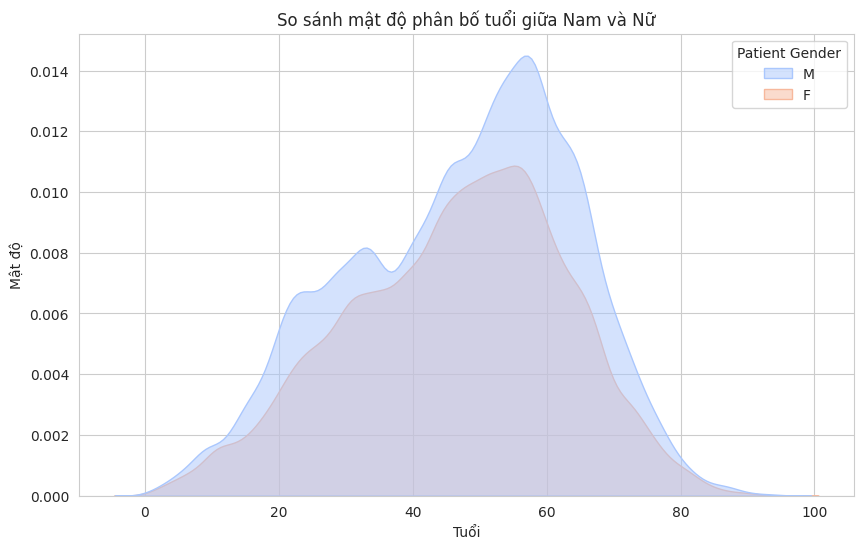

In [49]:
# Biểu đồ phân bố tuổi theo giới tính
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clean, x='Patient Age', hue='Patient Gender', fill=True, palette='coolwarm', alpha=0.5)
plt.title("So sánh mật độ phân bố tuổi giữa Nam và Nữ")
plt.xlabel("Tuổi")
plt.ylabel("Mật độ")
plt.show()

In [38]:
# 4. KIỂM TRA LIÊN KẾT ẢNH (PATH MAPPING)
print("\n--- KIỂM TRA FILE ẢNH TRÊN Ổ CỨNG ---")
# Quét toàn bộ file ảnh thật sự có trên Kaggle
all_image_paths = glob.glob(os.path.join(INPUT_DIR, '**/*.png'), recursive=True)
path_map = {os.path.basename(x): x for x in all_image_paths}

print(f"Đã tìm thấy {len(path_map)} file ảnh .png trên ổ cứng.")

# Thêm cột 'path' vào dataframe
df_clean['full_path'] = df_clean['Image Index'].map(path_map)

# Kiểm tra bao nhiêu dòng trong CSV không tìm thấy ảnh
missing_images = df_clean['full_path'].isnull().sum()
print(f"Số dòng trong CSV không tìm thấy ảnh: {missing_images}")

# Xóa các dòng không có ảnh
df_final = df_clean.dropna(subset=['full_path'])
print(f"Dữ liệu cuối cùng sẵn sàng để train: {len(df_final)} dòng.")


--- KIỂM TRA FILE ẢNH TRÊN Ổ CỨNG ---
Đã tìm thấy 112120 file ảnh .png trên ổ cứng.
Số dòng trong CSV không tìm thấy ảnh: 0
Dữ liệu cuối cùng sẵn sàng để train: 112104 dòng.


In [39]:
# TẠO CỘT 'path'
print("Đang tạo cột 'path' bằng cách quét ổ cứng...")
all_img_paths = glob.glob(os.path.join(INPUT_DIR, '**/*.png'), recursive=True)

# Tạo từ điển map: {'tên_file.png' : '/đường/dẫn/đầy/đủ/tên_file.png'}
path_map = {os.path.basename(x): x for x in all_img_paths}

# Gán cột 'path' vào dataframe (ĐÂY LÀ DÒNG BẠN BỊ THIẾU)
df_clean['path'] = df_clean['Image Index'].map(path_map)

# Kiểm tra xem có tạo được cột path chưa
if 'path' in df_clean.columns:
    print("Đã tạo thành công cột 'path'.")
else:
    print("LỖI: Vẫn chưa tạo được cột 'path'.")

# Loại bỏ các dòng mà không tìm thấy ảnh (path bị NaN)
df_clean = df_clean.dropna(subset=['path'])
print(f"-> Số dòng có ảnh thực tế: {len(df_clean)}")

Đang tạo cột 'path' bằng cách quét ổ cứng...
Đã tạo thành công cột 'path'.
-> Số dòng có ảnh thực tế: 112104


In [41]:
final_df = df_clean[['Image Index', 'Patient Age', 'path']].copy()

print("\n Dữ liệu sau khi chọn lọc cột:")
final_df.head()


 Dữ liệu sau khi chọn lọc cột:


,Image Index,Patient Age,path
0,00000001_000.png,58,/kaggle/input/data/images_001/images/00000001_...
1,00000001_001.png,58,/kaggle/input/data/images_001/images/00000001_...
2,00000001_002.png,58,/kaggle/input/data/images_001/images/00000001_...
3,00000002_000.png,81,/kaggle/input/data/images_001/images/00000002_...
4,00000003_000.png,81,/kaggle/input/data/images_001/images/00000003_...


Đang hiển thị lại ảnh mẫu...


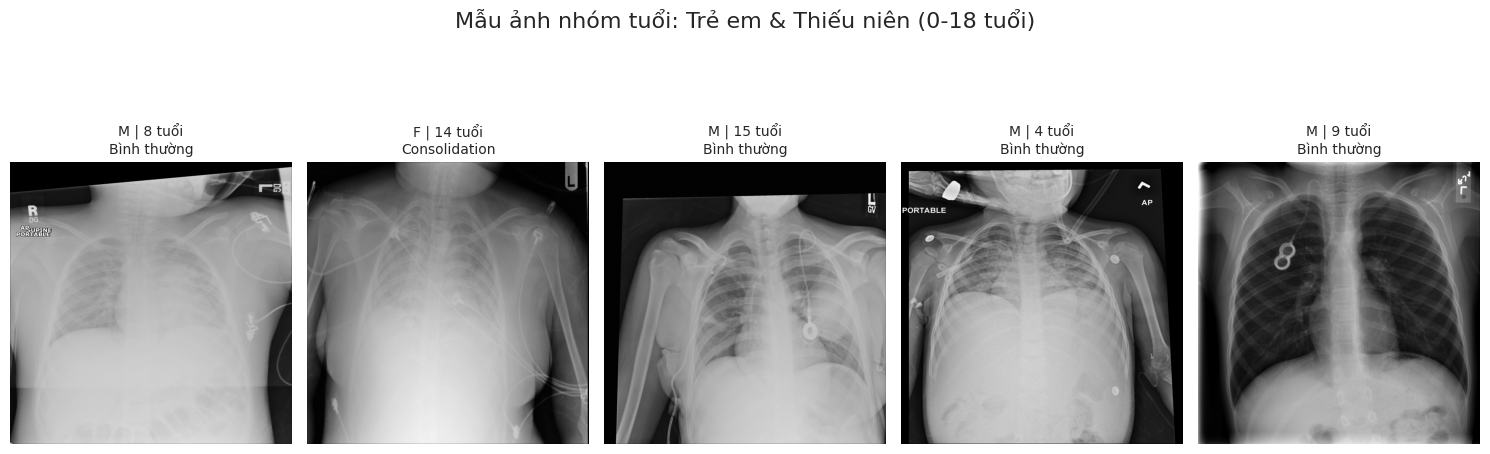

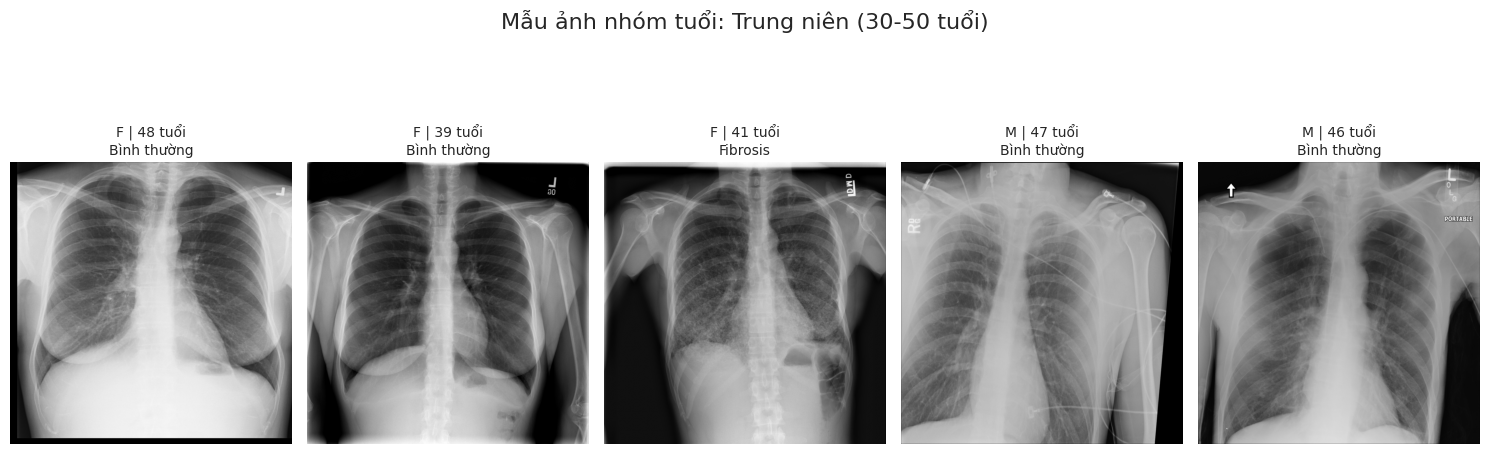

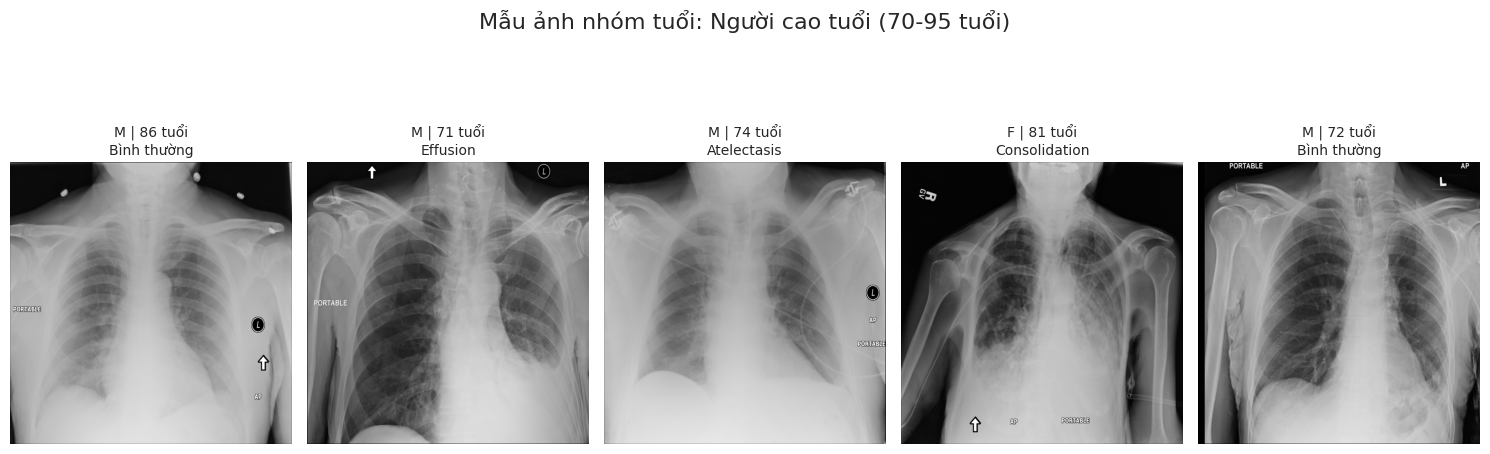

In [40]:
def show_sample_images(data, age_group_name, min_age, max_age, num_imgs=5):
    # Lấy mẫu ngẫu nhiên
    sample = data[(data['Patient Age'] >= min_age) & (data['Patient Age'] <= max_age)]
    
    # Nếu không đủ ảnh thì lấy hết số đang có
    if len(sample) < num_imgs:
        num_imgs = len(sample)
    
    sample = sample.sample(num_imgs)
    
    plt.figure(figsize=(15, 5)) 
    
    # Đẩy tiêu đề tổng lên cao một chút để không đè vào ảnh
    plt.suptitle(f"Mẫu ảnh nhóm tuổi: {age_group_name} ({min_age}-{max_age} tuổi)", fontsize=16, y=1.05)
    
    for i, (_, row) in enumerate(sample.iterrows()):
        img_path = row['full_path']
        try:
            img = Image.open(img_path)
            plt.subplot(1, num_imgs, i+1)
            plt.imshow(img, cmap='gray')
            
            # Làm gọn Finding Label (chỉ lấy bệnh đầu tiên nếu có nhiều bệnh)
            finding = row['Finding Labels'].split('|')[0]
            if finding == "No Finding": finding = "Bình thường"
            
            # Giảm font size và chỉnh lại nội dung
            plt.title(f"{row['Patient Gender']} | {row['Patient Age']} tuổi\n{finding}", fontsize=10)
            plt.axis('off')
        except:
            pass
    
    plt.tight_layout()
    plt.show()

# Chạy lại thử hiển thị
print("Đang hiển thị lại ảnh mẫu...")
show_sample_images(df_final, "Trẻ em & Thiếu niên", 0, 18)
show_sample_images(df_final, "Trung niên", 30, 50)
show_sample_images(df_final, "Người cao tuổi", 70, 95)

/tmp/ipykernel_55/1161058272.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Nhom_Tuoi', palette='viridis', ax=axes[0])


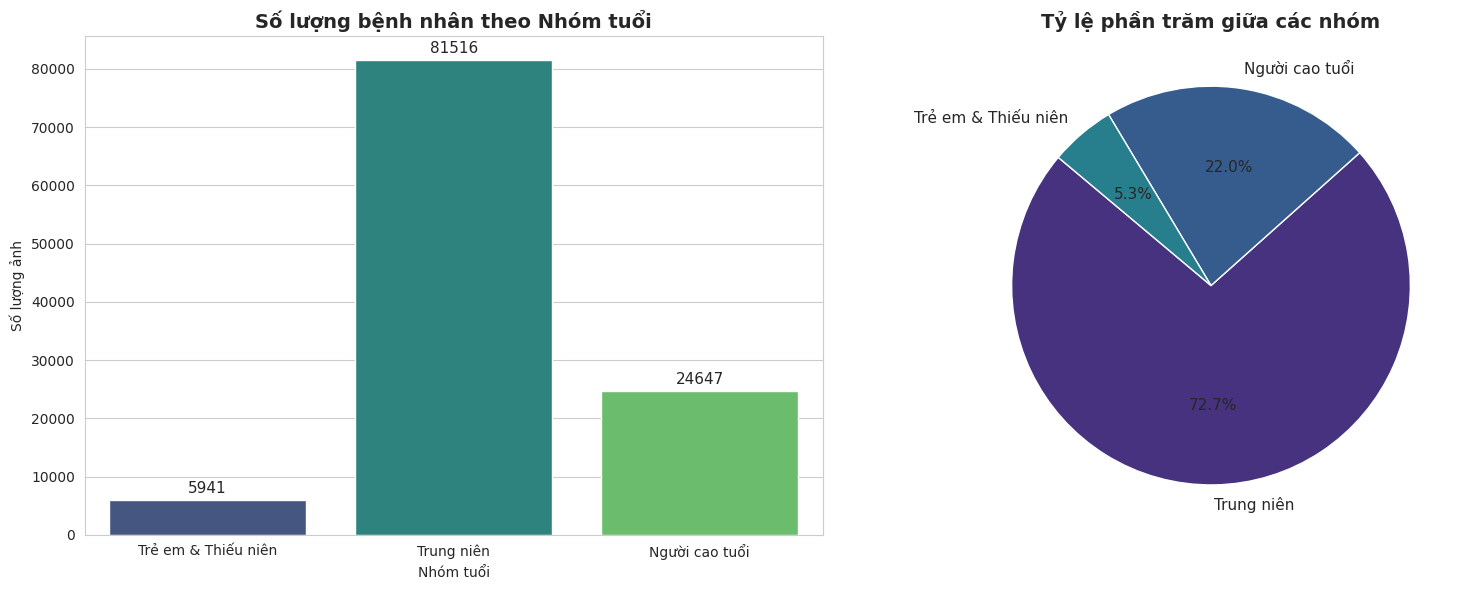

In [56]:
bins = [0, 18, 60, 120] 
labels = ['Trẻ em & Thiếu niên', 'Trung niên', 'Người cao tuổi']

# Tạo cột mới 'Nhom_Tuoi' cho df_final
df_final['Nhom_Tuoi'] = pd.cut(df_final['Patient Age'], bins=bins, labels=labels, right=True)

# VẼ BIỂU ĐỒ THỐNG KÊ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# --- BIỂU ĐỒ 1: SỐ LƯỢNG (Cột) ---
# Đếm số người trong từng nhóm
sns.countplot(data=df_final, x='Nhom_Tuoi', palette='viridis', ax=axes[0])
axes[0].set_title('Số lượng bệnh nhân theo Nhóm tuổi', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nhóm tuổi')
axes[0].set_ylabel('Số lượng ảnh')

# Thêm con số cụ thể trên đầu mỗi cột cho dễ nhìn
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, padding=3)

# --- BIỂU ĐỒ 2: TỶ LỆ (Tròn) ---
# Tính toán tỷ lệ phần trăm
group_counts = df_final['Nhom_Tuoi'].value_counts()

axes[1].pie(group_counts, 
            labels=group_counts.index, 
            autopct='%1.1f%%',  # Hiển thị số %
            startangle=140, 
            colors=sns.color_palette('viridis'),
            textprops={'fontsize': 11})
axes[1].set_title('Tỷ lệ phần trăm giữa các nhóm', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

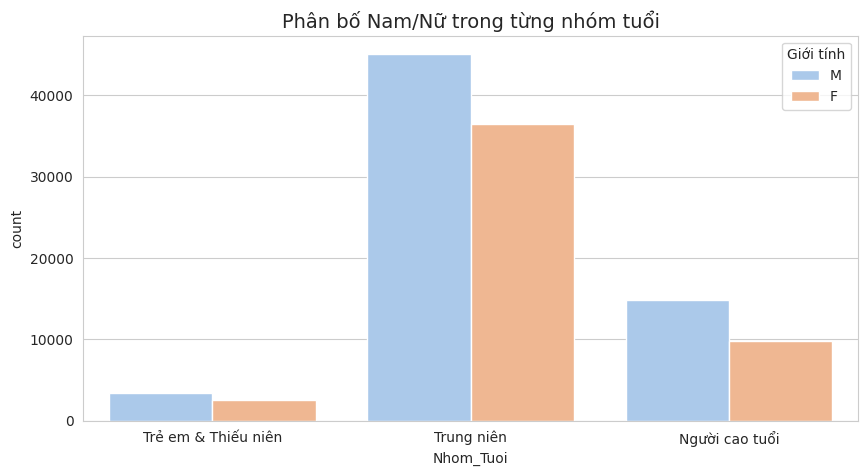

In [57]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_final, x='Nhom_Tuoi', hue='Patient Gender', palette='pastel')
plt.title("Phân bố Nam/Nữ trong từng nhóm tuổi", fontsize=14)
plt.legend(title='Giới tính')
plt.show()

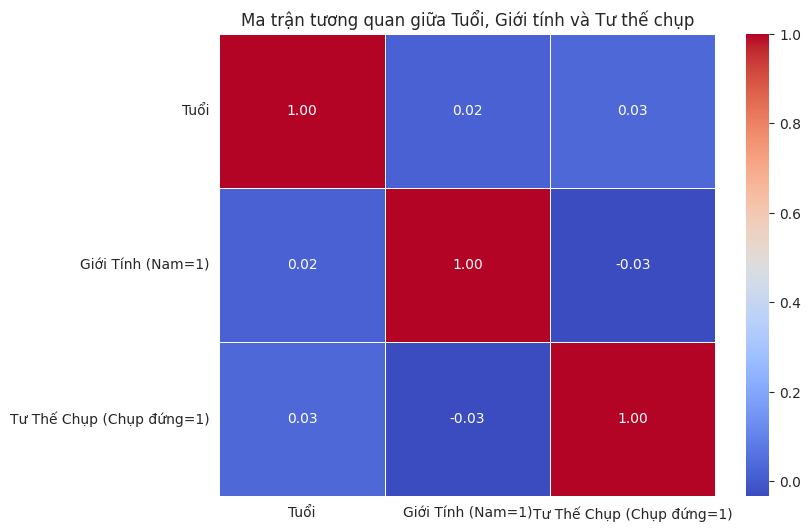

In [53]:
# Copy dữ liệu để không ảnh hưởng bảng gốc
df_corr = df_clean[['Patient Age', 'Patient Gender', 'View Position']].copy()

# Chuyển đổi sang số (Encoding)
df_corr['Gender_Code'] = df_corr['Patient Gender'].map({'M': 1, 'F': 0})     # Nam=1, Nữ=0
df_corr['View_PA'] = df_corr['View Position'].map({'PA': 1, 'AP': 0})        # PA (chụp đứng)=1, AP (chụp nằm)=0

df_corr = df_corr.rename(columns={
    'Patient Age': 'Tuổi',
    'Gender_Code': 'Giới Tính (Nam=1)',
    'View_PA': 'Tư Thế Chụp (Chụp đứng=1)'
})

# Tính ma trận tương quan
correlation = df_corr[['Tuổi', 'Giới Tính (Nam=1)', 'Tư Thế Chụp (Chụp đứng=1)']].corr()

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa Tuổi, Giới tính và Tư thế chụp")
plt.show()

In [46]:
# --- CẤU HÌNH ĐƯỜNG DẪN ---
INPUT_DIR = "/kaggle/input/data"
RAW_CSV_PATH = os.path.join(INPUT_DIR, "Data_Entry_2017.csv")
OUTPUT_DIR = "/kaggle/working/data/processed"

# Tạo thư mục output nếu chưa có
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [47]:
# 5. CHIA TẬP (SPLIT) & LƯU FILE
print("\n --- CHIA TẬP TRAIN/VAL/TEST ---")
# Chia Train (70%), Val (15%), Test (15%)
train_df, temp_df = train_test_split(final_df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train set: {len(train_df)}")
print(f"Val set:   {len(val_df)}")
print(f"Test set:  {len(test_df)}")


 --- CHIA TẬP TRAIN/VAL/TEST ---
Train set: 78472
Val set:   16816
Test set:  16816


In [48]:
# Lưu ra file CSV vào folder processed
train_df.to_csv(f"{OUTPUT_DIR}/train.csv", index=False)
val_df.to_csv(f"{OUTPUT_DIR}/val.csv", index=False)
test_df.to_csv(f"{OUTPUT_DIR}/test.csv", index=False)

print(f"\n Đã lưu xong 3 file CSV vào: {OUTPUT_DIR}")


 Đã lưu xong 3 file CSV vào: /kaggle/working/data/processed
